In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_frequency_beta05.txt')

In [48]:
df.head()

,representation,coding,train_size,val_size,seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,epoch,batch_size.1,loss,beta
0,n_bins,frequency,0.1,0.1,42,8,0,0,0.5871,0.5530,19,8,frequency,0.5
1,n_bins,frequency,0.3,0.1,42,8,0,0,0.5871,0.5682,17,8,frequency,0.5
2,n_bins,frequency,0.5,0.1,42,8,0,0,0.6856,0.6212,19,8,frequency,0.5
3,n_bins,frequency,0.7,0.1,42,8,0,0,0.7121,0.6629,23,8,frequency,0.5
4,n_bins,frequency,0.9,0.1,42,8,0,0,0.7008,0.6477,27,8,frequency,0.5


In [49]:
df = df.drop(['val_rate_acc', 'val_temp_acc', 'batch_size.1', 'coding'], axis=1)
df['epoch'] = df['epoch'] + 1

In [50]:
df.head()

,representation,train_size,val_size,seed,batch_size,test_rate_acc,test_temp_acc,epoch,loss,beta
0,n_bins,0.1,0.1,42,8,0.5871,0.5530,20,frequency,0.5
1,n_bins,0.3,0.1,42,8,0.5871,0.5682,18,frequency,0.5
2,n_bins,0.5,0.1,42,8,0.6856,0.6212,20,frequency,0.5
3,n_bins,0.7,0.1,42,8,0.7121,0.6629,24,frequency,0.5
4,n_bins,0.9,0.1,42,8,0.7008,0.6477,28,frequency,0.5


In [51]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'epoch': 'mean'
}).reset_index()

In [52]:
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,epoch
0,0.1,binary,0.127500,0.128767,16.0
1,0.1,n_bins,0.565633,0.534067,16.0
2,0.1,spike_count,0.483567,0.433100,16.0
3,0.1,time_window,0.463367,0.409067,16.0
4,0.1,timesurface,0.123733,0.125000,16.0


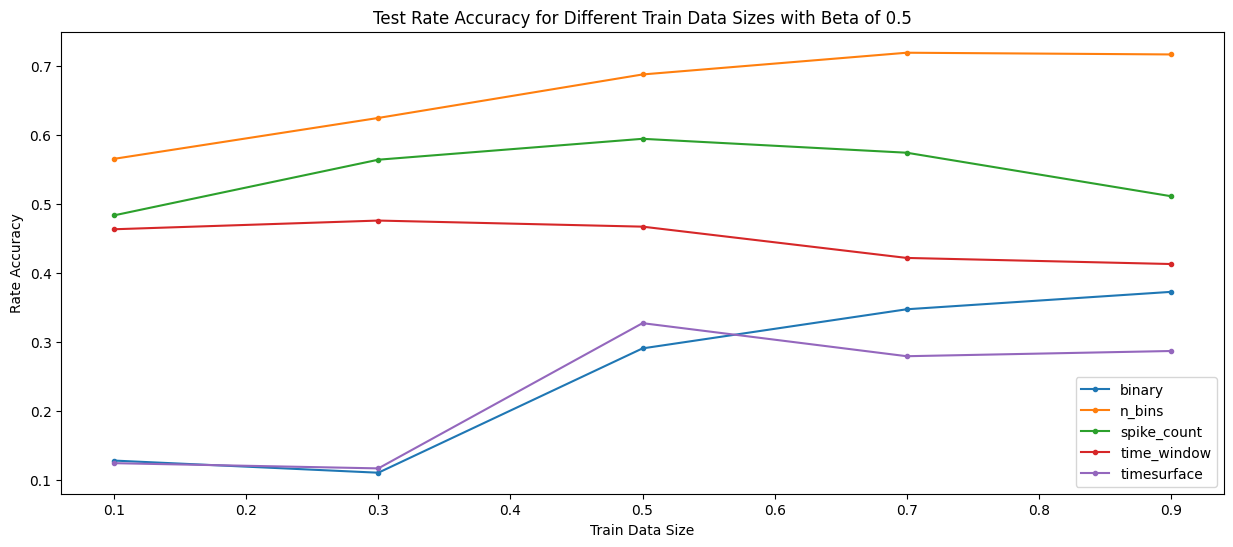

In [53]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

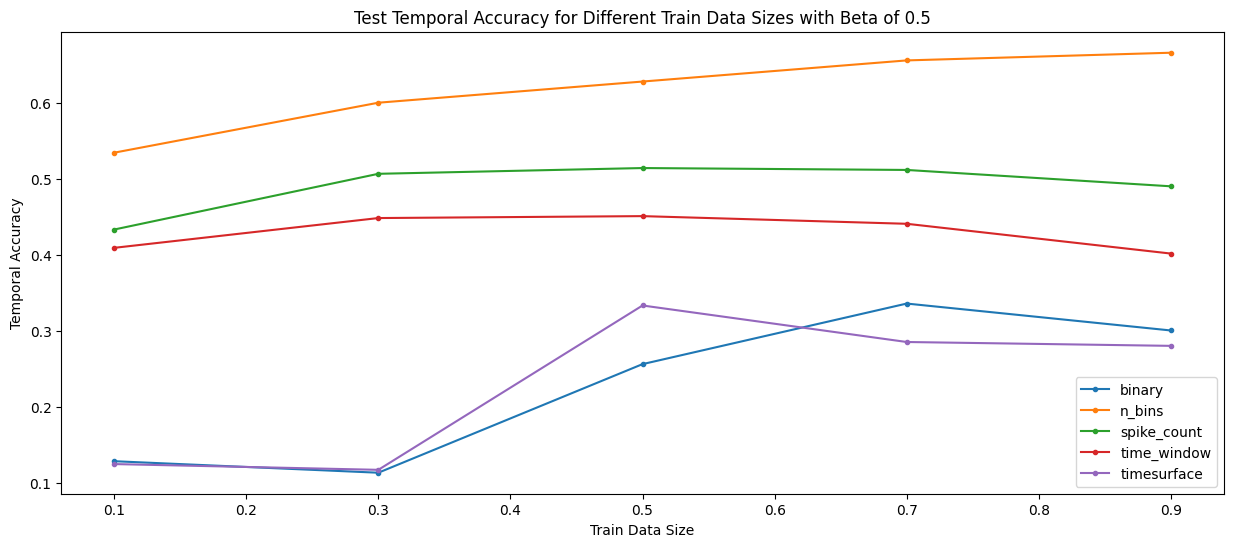

In [54]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

In [55]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_frequency_beta09.txt')

In [56]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1

In [57]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.1,0.1,13,binary,tensor(0.0909),tensor(0.0909),16,8
1,0.1,0.1,13,n_bins,tensor(0.5606),tensor(0.5303),16,8
2,0.1,0.1,13,spike_count,tensor(0.4621),tensor(0.4129),16,8
3,0.1,0.1,42,binary,tensor(0.1818),tensor(0.1856),20,8
4,0.1,0.1,42,n_bins,tensor(0.5871),tensor(0.5530),20,8


In [58]:
df['test_rate_acc'] = df['test_rate_acc'].str.extract(r'tensor\((.*?)\)').astype(float)
df['test_temp_acc'] = df['test_temp_acc'].str.extract(r'tensor\((.*?)\)').astype(float)

In [59]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.1,0.1,13,binary,0.0909,0.0909,16,8
1,0.1,0.1,13,n_bins,0.5606,0.5303,16,8
2,0.1,0.1,13,spike_count,0.4621,0.4129,16,8
3,0.1,0.1,42,binary,0.1818,0.1856,20,8
4,0.1,0.1,42,n_bins,0.5871,0.5530,20,8


In [60]:
grouped_data = df.groupby(['train_data_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'num_epochs': 'mean'
}).reset_index()

In [61]:
grouped_data.head()

,train_data_size,representation,test_rate_acc,test_temp_acc,num_epochs
0,0.1,binary,0.132556,0.130878,16.444444
1,0.1,n_bins,0.555967,0.539567,16.444444
2,0.1,spike_count,0.488620,0.432580,16.800000
3,0.1,time_window,0.470967,0.428033,17.333333
4,0.2,binary,0.093844,0.095111,14.888889


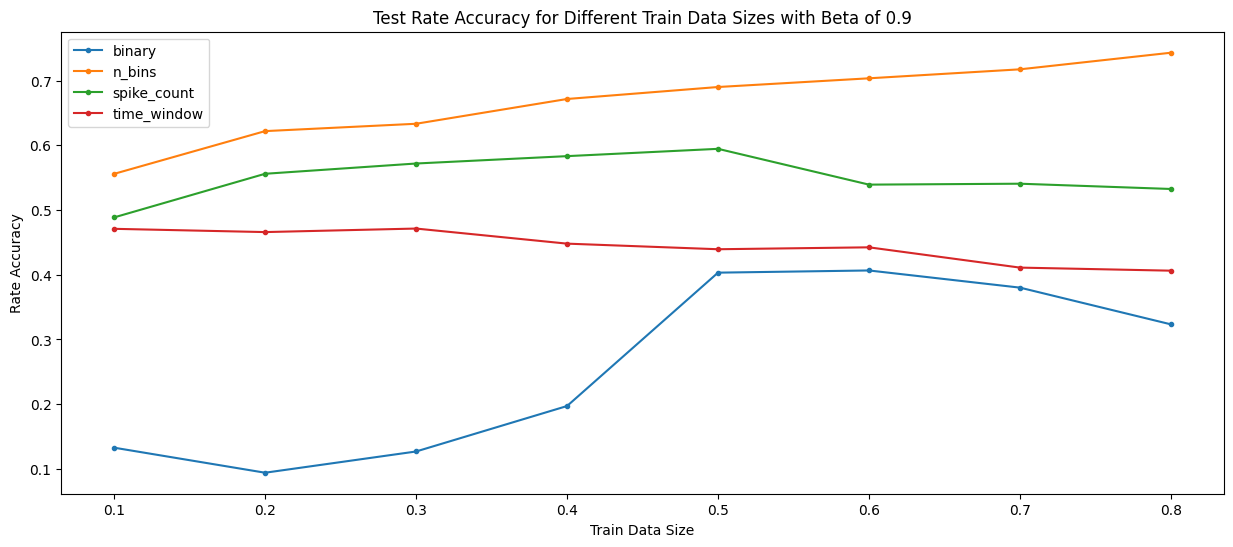

In [62]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

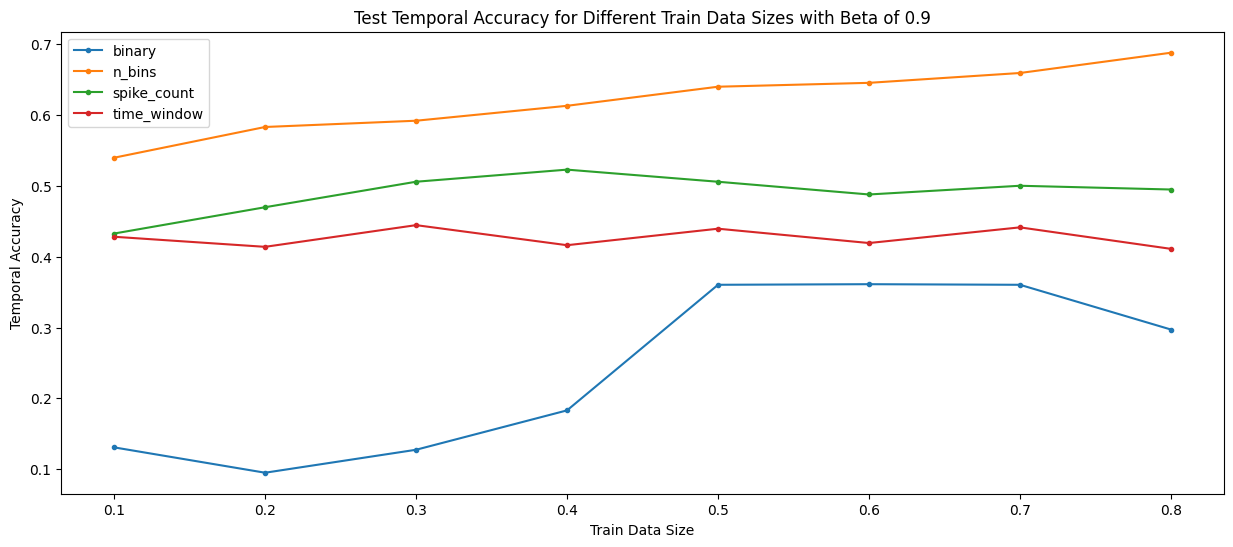

In [63]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

In [64]:
df = pd.read_csv("../results/dvs128_snn_09_batch8_freq_beta09.txt")

In [65]:
df.head()

,train_data_size,val_data_size,random_seed,representation,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.0,0.0,tensor(0.4318),tensor(0.3864),17,8
1,0.9,0.1,13,n_bins,0.0,0.0,tensor(0.7197),tensor(0.6591),17,8
2,0.9,0.1,13,spike_count,0.0,0.0,tensor(0.5417),tensor(0.5265),17,8
3,0.9,0.1,13,time_window,0.0,0.0,tensor(0.4394),tensor(0.4053),17,8
4,0.9,0.1,42,binary,0.0,0.0,tensor(0.4697),tensor(0.3333),27,8


In [66]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1

In [67]:
df['test_rate_acc'] = df['test_rate_acc'].str.extract(r'tensor\((.*?)\)').astype(float)
df['test_temp_acc'] = df['test_temp_acc'].str.extract(r'tensor\((.*?)\)').astype(float)

In [68]:
df.head()

,train_data_size,val_data_size,random_seed,representation,test_rate_acc,test_temp_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.4318,0.3864,18,8
1,0.9,0.1,13,n_bins,0.7197,0.6591,18,8
2,0.9,0.1,13,spike_count,0.5417,0.5265,18,8
3,0.9,0.1,13,time_window,0.4394,0.4053,18,8
4,0.9,0.1,42,binary,0.4697,0.3333,28,8


In [75]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()

In [76]:
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.384256  0.086133      0.341744  0.070226  23.777778
1         n_bins      0.716767  0.012675      0.673833  0.017311  23.777778
2    spike_count      0.511850  0.020593      0.476325  0.027283  24.000000
3    time_window      0.404900  0.017906      0.394800  0.019470  23.777778

C:\Users\osvat\AppData\Local\Temp\ipykernel_32856\2999479027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_32856\2999479027.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


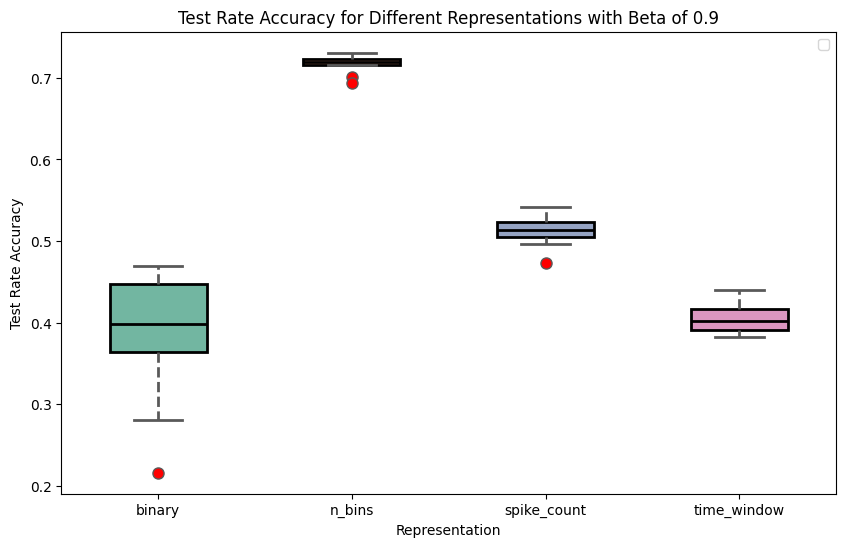

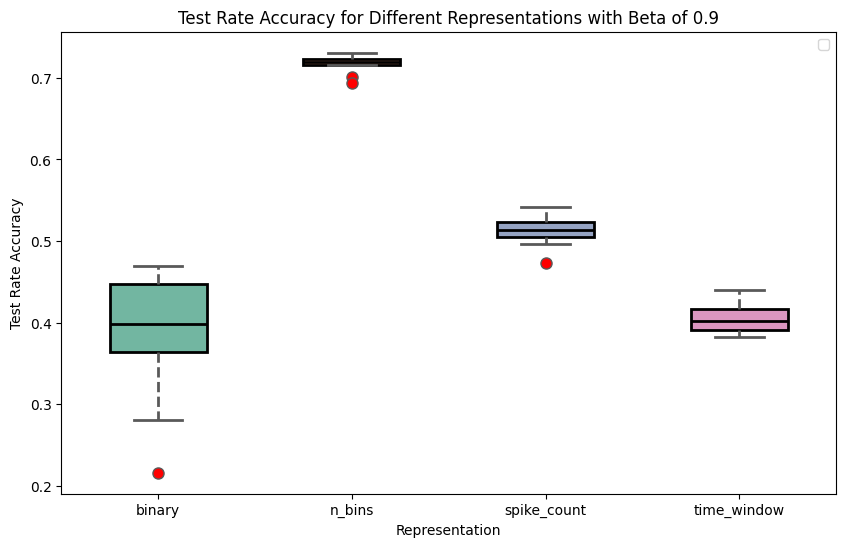

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

C:\Users\osvat\AppData\Local\Temp\ipykernel_32856\296180814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_32856\296180814.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


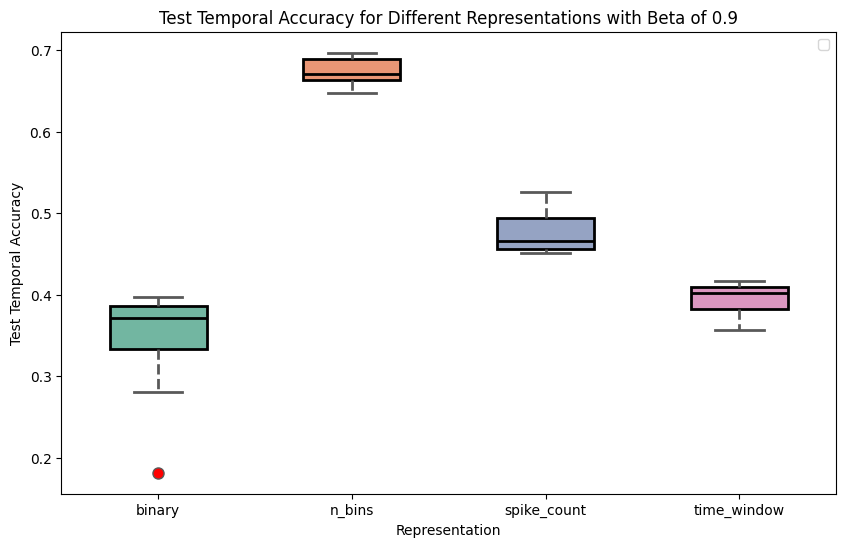

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_temp_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Temporal Accuracy')
ax.set_title('Test Temporal Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

In [82]:
grouped_data.to_csv("dvs128_snn_frequency_beta09_grouped.csv")

In [24]:
df = pd.read_csv("../results/dvs128_snn_09_batch8_frequency_beta05.txt")

In [25]:
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,frequency,0.9,0.1,42,8,0,0,0.7008,0.6477,27.0,8.0,frequency,0.5
1,binary,frequency,0.9,0.1,42,8,0,0,0.4697,0.3333,27.0,8.0,frequency,0.5
2,time_window,frequency,0.9,0.1,42,8,0,0,0.4167,0.4167,27.0,8.0,frequency,0.5
3,spike_count,frequency,0.9,0.1,42,8,0,0,0.4962,0.4924,27.0,8.0,frequency,0.5
4,timesurface,frequency,0.9,0.1,42,8,0,0,0.2689,0.2462,27.0,8.0,frequency,0.5


In [26]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,frequency,0.9,0.1,42,8,0.7008,0.6477,28.0,8.0,frequency,0.5
1,binary,frequency,0.9,0.1,42,8,0.4697,0.3333,28.0,8.0,frequency,0.5
2,time_window,frequency,0.9,0.1,42,8,0.4167,0.4167,28.0,8.0,frequency,0.5
3,spike_count,frequency,0.9,0.1,42,8,0.4962,0.4924,28.0,8.0,frequency,0.5
4,timesurface,frequency,0.9,0.1,42,8,0.2689,0.2462,28.0,8.0,frequency,0.5


In [27]:
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,frequency,0.9,0.1,42,8,0.7008,0.6477,28.0
1,binary,frequency,0.9,0.1,42,8,0.4697,0.3333,28.0
2,time_window,frequency,0.9,0.1,42,8,0.4167,0.4167,28.0
3,spike_count,frequency,0.9,0.1,42,8,0.4962,0.4924,28.0
4,timesurface,frequency,0.9,0.1,42,8,0.2689,0.2462,28.0


C:\Users\osvat\AppData\Local\Temp\ipykernel_20108\3529193584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_20108\3529193584.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


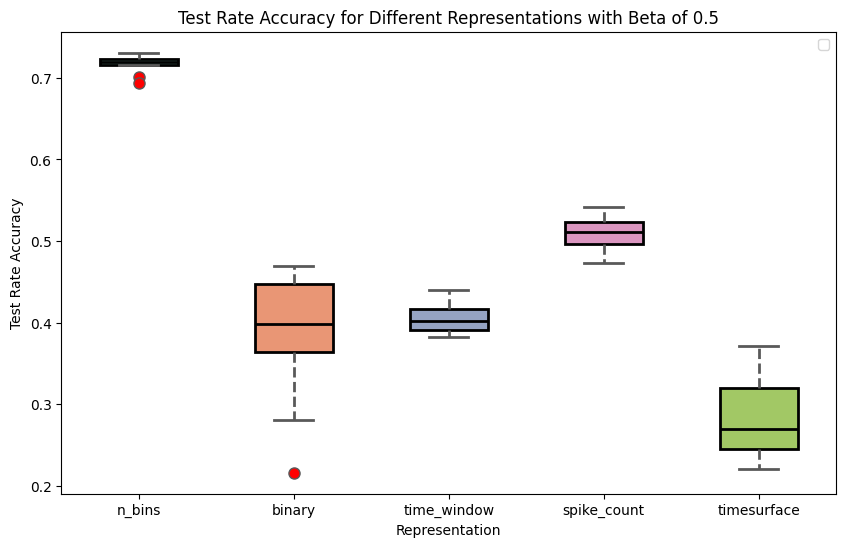

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.5')
ax.legend()
plt.show()

In [29]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()

In [30]:
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.384256  0.086133      0.341744  0.070226  23.777778
1         n_bins      0.716767  0.012675      0.673833  0.017311  23.777778
2    spike_count      0.510111  0.019957      0.473489  0.026902  23.777778
3    time_window      0.404900  0.017906      0.394800  0.019470  23.777778
4    timesurface      0.286600  0.077285      0.280300  0.079536  22.666667

In [32]:
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.38  0.09          0.34  0.07      23.78
1         n_bins          0.72  0.01          0.67  0.02      23.78
2    spike_count          0.51  0.02          0.47  0.03      23.78
3    time_window          0.40  0.02          0.39  0.02      23.78
4    timesurface          0.29  0.08          0.28  0.08      22.67

In [33]:
grouped_data.to_csv("dvs128_snn_frequency_beta05_grouped.csv")